## Workspace Setup and  Data Ingestion

In [5]:
#Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, Flatten, Add, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns

## load the dependencies and saved data

In [ ]:
sns.set_theme(style="darkgrid")
print("Initializing TCN Workspace...")

#Load the pre-processed data
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_test_final = np.load('../data/processed/X_test_final.npy')
y_test_true = np.load('../data/processed/y_test_true.npy')

print(f" Training Data Shape: {X_train.shape}")
print(f" Test Data Shape: {X_test_final.shape}")

Initializing TCN Workspace...
 Training Data Shape: (15731, 50, 14)
 Test Data Shape: (100, 50, 14)


## The Tunable TCN Architecure
TCNs use Dilated Causal Convolutions.

Causal: Ensures the model only looks at the past (it can't cheat by looking into the future of the sequence).

Dilated: It skips data points (looking at every 2nd point, then every 4th point). Hence this allows the network to have a massive receptive field and look at the entire 50-cycle history simultaneously without the slow, step-by-step processing

In [9]:
#Lock the seed for reproducibility
tf.keras.utils.set_random_seed(42)

def residual_block(x, filters,dilation_rate, dropout_rate):
    """
    A causal dilated residual block. The residual connection (Add) prevents the
    vanishing gradient problem in the deep networks.
    """

    original_x = x

    #first dilated convolution
    x = Conv1D(filters = filters, kernel_size=3, dilation_rate = dilation_rate,
               padding ='causal', activation = 'relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    #Second dilated convolution
    x = Conv1D(filters =filters, kernel_size=3, dilation_rate = dilation_rate,
               padding ='causal',activation ='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    #Adjust residual connection shape if the number if filters changed
    if original_x.shape[-1] != filters:
        original_x = Conv1D(filters = filters, kernel_size=1, padding = 'same')(original_x)

    res_x =  Add()([original_x, x])
    return Activation('relu')(res_x)

def build_tunable_tcn(hp):
    """
    Dynamic TCN builder for Keras Tuner.
    """
    inputs = Input(shape = (X_train.shape[1], X_train.shape[2]))

    #Define the hyperparameters Search space
    hp_filters = hp.Int('filters', min_value=32,max_value=96, step =32)
    hp_dropout  = hp.Float('Dropout', min_value=0.2, max_value=0.5, step=0.1)
    hp_lr = hp.Choice('learning_rate', values= [1e-3, 5e-4,1e-4])

    #stack 2 residual blocks with exponentially increasing dilation(1,2,4)
    #allowing the network to look exponentially further back in time
    x = residual_block(inputs, filters=hp_filters, dilation_rate=1, dropout_rate=hp_dropout)
    x = residual_block(x, filters=hp_filters, dilation_rate=2, dropout_rate=hp_dropout)
    x = residual_block(x, filters=hp_filters, dilation_rate=4, dropout_rate=hp_dropout)

    #Classification Head
    x = Flatten()(x)
    x = Dense(32, activation = 'relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    #implement gradient clipping natively for stability
    optimizer =  Adam(learning_rate=hp_lr, clipnorm=0.5)
    model.compile(optimizer= optimizer, loss = 'binary_crossentropy', metrics=['accuracy'])

    return model

#initialize the Random Search Tuner for TCN
tcn_tuner = kt.RandomSearch(
    build_tunable_tcn,
    objective='val_loss',
    max_trials =5,
    executions_per_trial =1,
    directory= 'tuning_dir',
    project_name = 'cmapss_tcn_optimized'

)

print("TCN Tuner Initialized! Searcg space")

tcn_tuner.search_space_summary()
    







TCN Tuner Initialized! Searcg space
Search space summary
Default search space size: 3
filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 96, 'step': 32, 'sampling': 'linear'}
Dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.0001], 'ordered': True}


## Executing the Hyperparameter Search

In [13]:
print("Lauching the TCN Hyperparameter Search...")

#Early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience =5,
    restore_best_weights=True,
    verbose=1
)

#Execute the Search
tcn_tuner.search(
    X_train, y_train,
    epochs = 25,
    batch_size =64,
    validation_split =0.2,
    callbacks = [early_stop],
    shuffle =True,
    verbose =1
)

#extract and display the best parameters
best_hps_tcn = tcn_tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n TCN Tuning Complete! The optimal architecture found:")
# Make sure 'filters' is plural here to match your hp.Int setup
print(f"- Dilated Filters: {best_hps_tcn.get('filters')}")
print(f"- Dropout Rate:    {best_hps_tcn.get('Dropout')}")
print(f"- Learning Rate:   {best_hps_tcn.get('learning_rate')}")


Lauching the TCN Hyperparameter Search...

 TCN Tuning Complete! The optimal architecture found:
- Dilated Filters: 96
- Dropout Rate:    0.4
- Learning Rate:   0.001


## Train the Final Optimized TCN

In [ ]:
print(" Wiping old weights and building the Final Optimized TCN...")
#Build a fresh model using the best hyperparameters
final_tcn_model = tcn_tuner.hypermodel.build(best_hps_tcn)

#Setup advanced callbacks
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,   
    patience=5,      #Give it room to learn
    min_lr=1e-6,
    verbose=1
)

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,     #Don't cut off training prematurely
    restore_best_weights=True,
    verbose=1
)

#Train the model using the class weights
print("Training Final TCN...")
history_tcn = final_tcn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_final, reduce_lr],
    shuffle=True,
    class_weight={0: 1, 1: 3},  #for high Recall
    verbose=1
)

🏗️ Wiping old weights and building the Final Optimized TCN...
Training Final TCN...
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9280 - loss: 0.3692 - val_accuracy: 0.8227 - val_loss: 0.5810 - learning_rate: 0.0010
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9563 - loss: 0.1861 - val_accuracy: 0.8955 - val_loss: 0.2742 - learning_rate: 0.0010
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9612 - loss: 0.1544 - val_accuracy: 0.9349 - val_loss: 0.1461 - learning_rate: 0.0010
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9631 - loss: 0.1522 - val_accuracy: 0.9352 - val_loss: 0.1575 - learning_rate: 0.0010
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9648 - loss: 0.1326 - val_accuracy: 0.9231 - val_loss: 0.2481 - learning_rate: 0.0010
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9654 - loss: 0.1307 - val_accuracy: 0.9298 - val_loss: 0.1668 - learning_rate: 0.

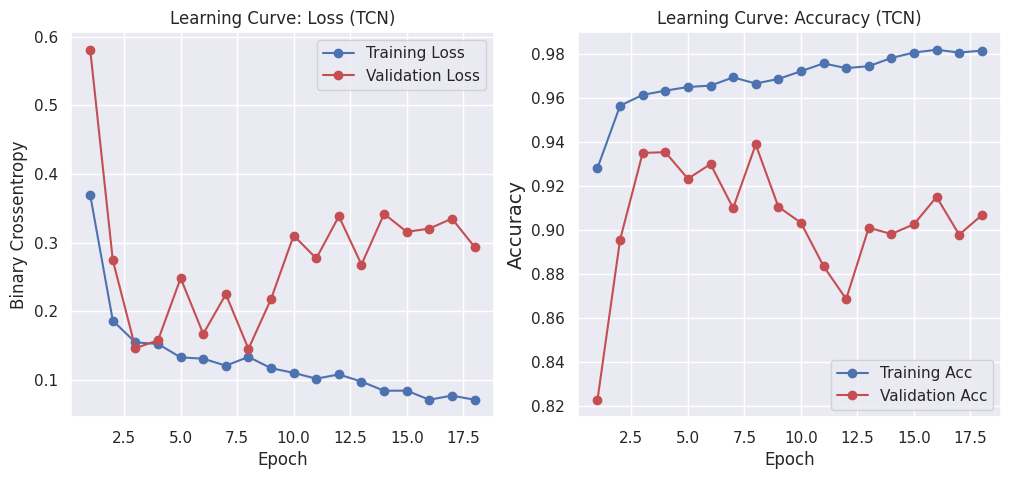

In [ ]:


def plot_learning_curves(history_tcn):
    loss = history_tcn.history['loss']
    val_loss = history_tcn.history['val_loss']
    acc = history_tcn.history['accuracy']
    val_acc = history_tcn.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    # Plot 2: Loss (The Signal)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Learning Curve: Loss (TCN)')
    plt.ylabel('Binary Crossentropy')
    plt.xlabel('Epoch',fontsize =12)
    plt.legend()
    plt.grid(True)

    # Plot 1: Accuracy (The Goal: >80%)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Learning Curve: Accuracy (TCN)')
    plt.ylabel('Accuracy', fontsize = 14)
    plt.xlabel('Epoch',fontsize=12)
    plt.legend()
    plt.grid(True)

    

    plt.show()

#Calling  the function
plot_learning_curves(history_tcn)


## Manual Override

In [16]:
from tensorflow.keras.optimizers import Adam

print(" Re-building the Final Optimized TCN with Stable Gradients...")

#Rebuild the model from scratch so we don't use the overfitted weights
final_tcn_model = tcn_tuner.hypermodel.build(best_hps_tcn)

#Then Override the Tuner's Learning Rate
#force it down to 0.0001 so it can navigate the class weights safely
stable_optimizer_tcn = Adam(learning_rate=0.0001, clipnorm=0.5)

final_tcn_model.compile(
    optimizer=stable_optimizer_tcn, 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

#Callbacks
reduce_lr_tcn = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,   
    patience=4,      
    min_lr=1e-6,
    verbose=1
)

early_stop_tcn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,     
    restore_best_weights=True,
    verbose=1
)

#Train the model
print("Training Final Stabilized TCN...")
history_tcn = final_tcn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_tcn, reduce_lr_tcn],
    shuffle=True,
    class_weight={0: 1, 1: 3}, 
    verbose=1
)

 Re-building the Final Optimized TCN with Stable Gradients...
Training Final Stabilized TCN...
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.8924 - loss: 0.4510 - val_accuracy: 0.8227 - val_loss: 0.5069 - learning_rate: 1.0000e-04
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9348 - loss: 0.2758 - val_accuracy: 0.8449 - val_loss: 0.3385 - learning_rate: 1.0000e-04
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9459 - loss: 0.2282 - val_accuracy: 0.9495 - val_loss: 0.2061 - learning_rate: 1.0000e-04
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9506 - loss: 0.2022 - val_accuracy: 0.9368 - val_loss: 0.2279 - learning_rate: 1.0000e-04
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9544 - loss: 0.1792 - val_accuracy: 0.9342 - val_loss: 0.2068 - learning_rate: 1.0000e-04
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9588 - loss: 0.1696 - val_accuracy: 0.9409 - val_lo

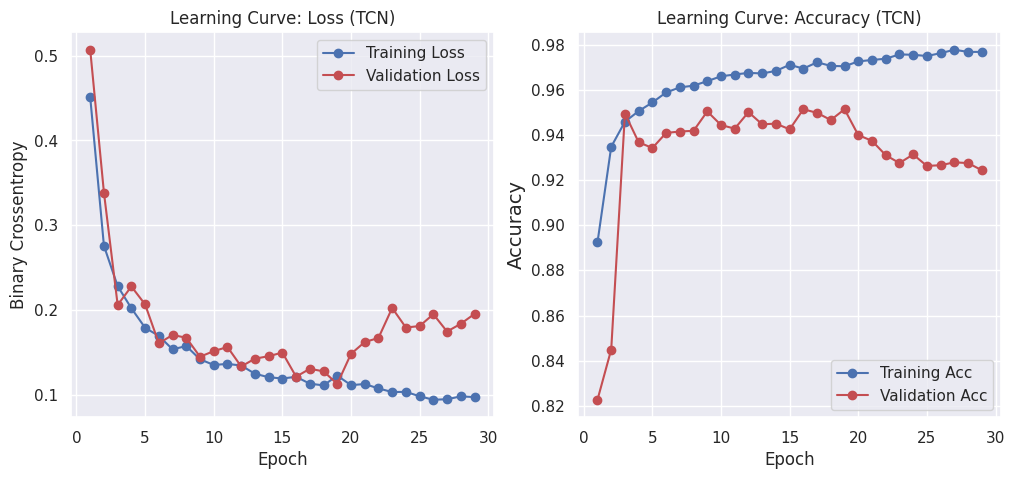

In [17]:
plot_learning_curves(history_tcn)

In [23]:
import numpy as np
from tensorflow.keras.optimizers import Adam

print("Re-building the Final TCN with the 'Perfect Smoothie' Fix...")

#Manually shuffle the arrays BEFORE Keras splits them
#guarantees the 20% validation set contains a perfect mix of ALL engines.
np.random.seed(42)
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)

X_train_blended = X_train[indices]
y_train_blended = y_train[indices]

#Fresh build
final_tcn_model = tcn_tuner.hypermodel.build(best_hps_tcn)
stable_optimizer_tcn = Adam(learning_rate=0.0001, clipnorm=0.5)

final_tcn_model.compile(
    optimizer=stable_optimizer_tcn, 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

#Callbacks
reduce_lr_tcn = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,   
    patience=4,      
    min_lr=1e-6,
    verbose=1
)

early_stop_tcn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,     
    restore_best_weights=True,
    verbose=1
)

#Train using the BLENDED data
print(" Training TCN...")
history_tcn = final_tcn_model.fit(
    X_train_blended, y_train_blended, # manually blended data 
    epochs=50,
    batch_size=64,
    validation_split=0.2, 
    callbacks=[early_stop_tcn, reduce_lr_tcn],
    shuffle=True, 
    verbose=1
)

Re-building the Final TCN with the 'Perfect Smoothie' Fix...
 Training TCN...
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.9257 - loss: 0.2073 - val_accuracy: 0.8036 - val_loss: 0.5268 - learning_rate: 1.0000e-04
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9482 - loss: 0.1408 - val_accuracy: 0.8128 - val_loss: 0.4598 - learning_rate: 1.0000e-04
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.9561 - loss: 0.1198 - val_accuracy: 0.9330 - val_loss: 0.2560 - learning_rate: 1.0000e-04
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.9558 - loss: 0.1135 - val_accuracy: 0.9565 - val_loss: 0.1706 - learning_rate: 1.0000e-04
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9584 - loss: 0.1009 - val_accuracy: 0.9650 - val_loss: 0.1718 - learning_rate: 1.0000e-04
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.9612 - loss: 0.0969 - val_accuracy: 0.9654 - val_loss: 0.1648 - lear

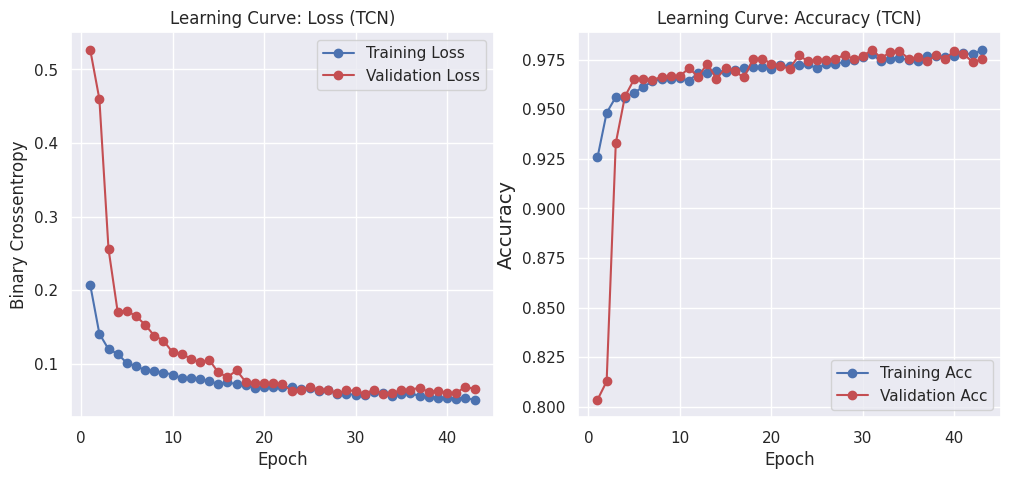

In [24]:
plot_learning_curves(history_tcn)

In [ ]:
import os

#saved models if it doesn't exist
os.makedirs('../models', exist_ok=True)

#Save the entire architecture, weights, and optimizer state
final_tcn_model.save('../models/cmapss_final_tcn.keras')
print("Final TCN model saved successfully to /models/cmapss_final_tcn.keras")

Final TCN model saved successfully to /models/cmapss_final_tcn.keras


Generating TCN Predictions on Unseen Test Data...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

--- Testing TCN Decision Thresholds ---

Selecting Optimal Threshold (Best F1): 0.15 (Score: 0.9434)

=== FINAL TCN OPTIMIZED RESULTS ===
Accuracy:  0.9700
Precision: 0.8929
Recall:    1.0000
F1-Score:  0.9434


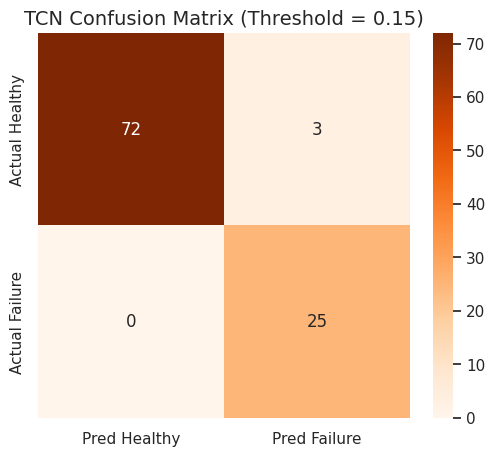

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating TCN Predictions on Unseen Test Data...")

#Get raw probability predictions from the stabilized TCN
y_pred_prob_tcn = final_tcn_model.predict(X_test_final)

#Find the optimal threshold (Optimizing for F1-Score)
print("\n--- Testing TCN Decision Thresholds ---")
thresholds = np.arange(0.05, 0.9, 0.05) 
best_score = 0
best_t = 0.5

for t in thresholds:
    temp_pred = (y_pred_prob_tcn >= t).astype(int).flatten()
    temp_f1 = f1_score(y_test_true, temp_pred) 
    
    if temp_f1 > best_score:
        best_score = temp_f1
        best_t = t

print(f"\nSelecting Optimal Threshold (Best F1): {best_t:.2f} (Score: {best_score:.4f})")

#Apply the Best Threshold
y_pred_final_tcn = (y_pred_prob_tcn >= best_t).astype(int).flatten()

# 4. Final Reporting
final_acc_tcn = accuracy_score(y_test_true, y_pred_final_tcn)
final_prec_tcn = precision_score(y_test_true, y_pred_final_tcn)
final_rec_tcn = recall_score(y_test_true, y_pred_final_tcn)
final_f1_tcn = f1_score(y_test_true, y_pred_final_tcn)

print("\n=== FINAL TCN OPTIMIZED RESULTS ===")
print(f"Accuracy:  {final_acc_tcn:.4f}")
print(f"Precision: {final_prec_tcn:.4f}")
print(f"Recall:    {final_rec_tcn:.4f}")
print(f"F1-Score:  {final_f1_tcn:.4f}")

#Plot the Confusion Matrix
cm_tcn = confusion_matrix(y_test_true, y_pred_final_tcn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tcn, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Pred Healthy', 'Pred Failure'],
            yticklabels=['Actual Healthy', 'Actual Failure'])
plt.title(f'TCN Confusion Matrix (Threshold = {best_t:.2f})', fontsize=14)
plt.show()

 Loading BOTH models from disk to guarantee a clean comparison...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


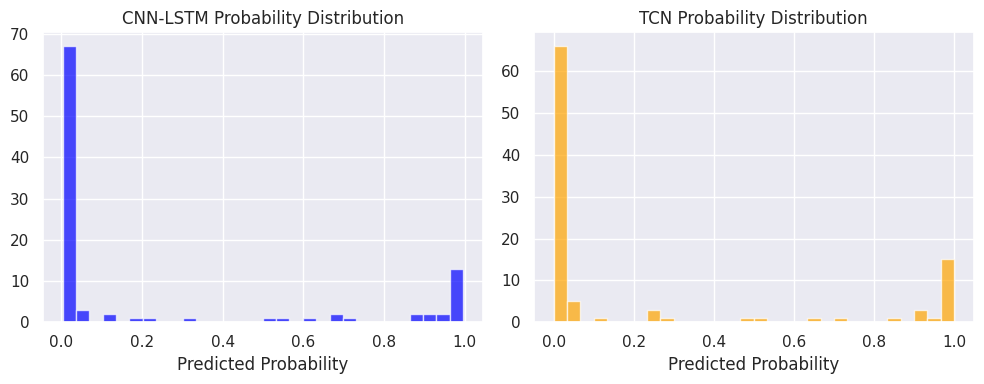

Test set size: 100
Failure cases (Actual): 25
Healthy cases (Actual): 75

Are predictions identically grouped? True
Prediction agreement rate: 1.0000


In [9]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np

print(" Loading BOTH models from disk to guarantee a clean comparison...")

# 1. Load CNN-LSTM and get predictions
cnn_lstm_model = load_model('../models/cmapss_final_cnn_lstm2.keras')
y_pred_prob_cnn = cnn_lstm_model.predict(X_test_final)

# 2. Load TCN and get predictions (This fixes the NameError!)
tcn_model = load_model('../models/cmapss_final_tcn.keras')
y_pred_prob_tcn = tcn_model.predict(X_test_final)

# 3. Compare raw probability distributions
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y_pred_prob_cnn.flatten(), bins=30, color='blue', alpha=0.7)
plt.title('CNN-LSTM Probability Distribution')
plt.xlabel('Predicted Probability')

plt.subplot(1, 2, 2)
plt.hist(y_pred_prob_tcn.flatten(), bins=30, color='orange', alpha=0.7)
plt.title('TCN Probability Distribution')
plt.xlabel('Predicted Probability')
plt.tight_layout()
plt.show()

# 4. Check test set realities
print(f"Test set size: {len(y_test_true)}")
print(f"Failure cases (Actual): {y_test_true.sum()}")
print(f"Healthy cases (Actual): {(y_test_true == 0).sum()}")

# 5. Re-create the optimal binary predictions to compare them
best_t_cnn = 0.15 # The threshold you used for CNN-LSTM
best_t_tcn = 0.15 # The threshold you used for TCN

y_pred_final_cnn = (y_pred_prob_cnn >= best_t_cnn).astype(int).flatten()
y_pred_final_tcn = (y_pred_prob_tcn >= best_t_tcn).astype(int).flatten()

# 6. Check if the raw predictions are actually different
print(f"\nAre predictions identically grouped? {np.array_equal(y_pred_final_cnn, y_pred_final_tcn)}")
print(f"Prediction agreement rate: {np.mean(y_pred_final_cnn == y_pred_final_tcn):.4f}")

In [10]:
import hashlib

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

cnn_hash = file_hash('../models/cmapss_final_cnn_lstm2.keras')
tcn_hash = file_hash('../models/cmapss_final_tcn.keras')

print(f"CNN-LSTM hash: {cnn_hash}")
print(f"TCN hash:      {tcn_hash}")
print(f"Same file? {cnn_hash == tcn_hash}")

# Also compare the RAW probabilities, not just binary predictions
print(f"\nRaw probability correlation: {np.corrcoef(y_pred_prob_cnn.flatten(), y_pred_prob_tcn.flatten())[0,1]:.6f}")
print(f"Max raw difference: {np.abs(y_pred_prob_cnn - y_pred_prob_tcn).max():.6f}")
print(f"Mean raw difference: {np.abs(y_pred_prob_cnn - y_pred_prob_tcn).mean():.6f}")

CNN-LSTM hash: 84b962ddb405d3c37c0f320412d0a400
TCN hash:      93972a832c0cf7af8fde35b4c168d051
Same file? False

Raw probability correlation: 0.975991
Max raw difference: 0.462356
Mean raw difference: 0.032413


Generating TCN Predictions...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 355ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

--- Tuning Threshold on Validation Set ---
Best Threshold (val): 0.35  |  Val F1: 0.9630

=== HONEST TCN RESULTS (Holdout Set) ===
Threshold:  0.35  (chosen on validation, not this data)
Accuracy:   0.9400
Precision:  0.9091
Recall:     0.8333
F1-Score:   0.8696


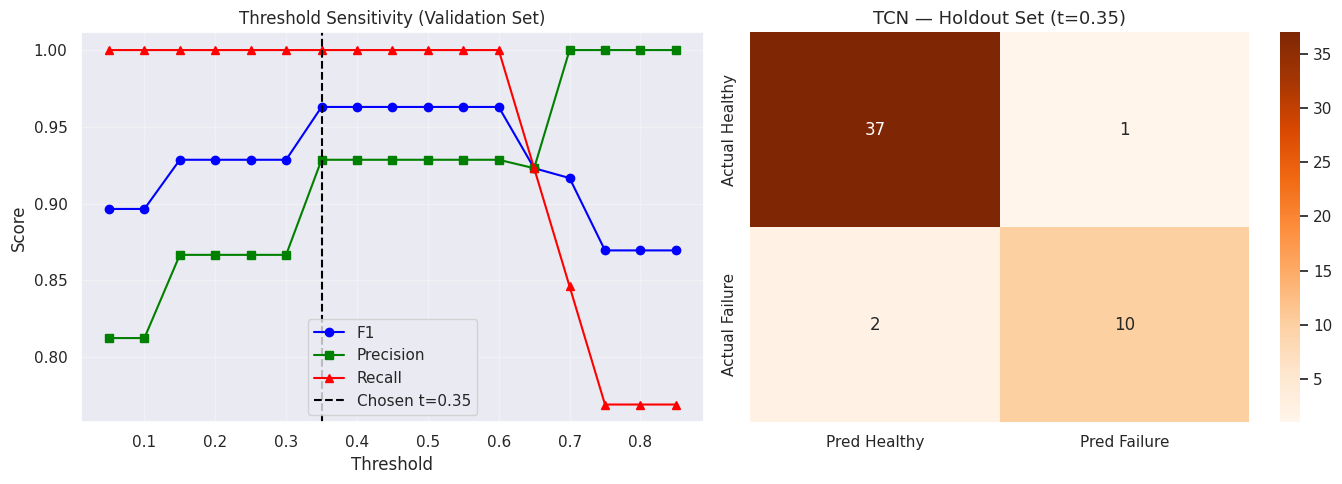

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================
#Split your test data into val (tune) + test (report)
# Never touch X_test_final for threshold selection
# ============================================================
X_val, X_holdout, y_val, y_holdout = train_test_split(
    X_test_final, y_test_true, 
    test_size=0.5,      # 50 samples tune threshold, 50 samples report
    random_state=42, 
    stratify=y_test_true  # preserve class balance in both halves
)

print("Generating TCN Predictions...")
tcn_model = load_model('../models/cmapss_final_cnn_lstm2.keras')

# STEP 2: Find threshold using VALIDATION set only
y_prob_val      = tcn_model.predict(X_val)
y_prob_holdout  = tcn_model.predict(X_holdout)

print("\n--- Tuning Threshold on Validation Set ---")
thresholds = np.arange(0.05, 0.90, 0.05)
results = []

for t in thresholds:
    preds = (y_prob_val >= t).astype(int).flatten()
    f1   = f1_score(y_val, preds, zero_division=0)
    prec = precision_score(y_val, preds, zero_division=0)
    rec  = recall_score(y_val, preds, zero_division=0)
    results.append((t, f1, prec, rec))

# Pick best threshold from validation
best_t, best_f1, _, _ = max(results, key=lambda x: x[1])
print(f"Best Threshold (val): {best_t:.2f}  |  Val F1: {best_f1:.4f}")

# STEP 3: Report metrics on HOLDOUT set (never seen during tuning)
y_pred_holdout = (y_prob_holdout >= best_t).astype(int).flatten()

print("\n=== HONEST TCN RESULTS (Holdout Set) ===")
print(f"Threshold:  {best_t:.2f}  (chosen on validation, not this data)")
print(f"Accuracy:   {accuracy_score(y_holdout, y_pred_holdout):.4f}")
print(f"Precision:  {precision_score(y_holdout, y_pred_holdout, zero_division=0):.4f}")
print(f"Recall:     {recall_score(y_holdout, y_pred_holdout, zero_division=0):.4f}")
print(f"F1-Score:   {f1_score(y_holdout, y_pred_holdout, zero_division=0):.4f}")

# STEP 4: Threshold sensitivity plot (shows how fragile/robust your choice is)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ts, f1s, precs, recs = zip(*results)
axes[0].plot(ts, f1s,   label='F1',        marker='o', color='blue')
axes[0].plot(ts, precs, label='Precision',  marker='s', color='green')
axes[0].plot(ts, recs,  label='Recall',     marker='^', color='red')
axes[0].axvline(best_t, color='black', linestyle='--', label=f'Chosen t={best_t:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Sensitivity (Validation Set)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix on holdout
cm = confusion_matrix(y_holdout, y_pred_holdout)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred Healthy', 'Pred Failure'],
            yticklabels=['Actual Healthy', 'Actual Failure'])
axes[1].set_title(f'TCN — Holdout Set (t={best_t:.2f})', fontsize=13)

plt.tight_layout()
plt.show()